In [1]:
from sklearn import datasets
from sklearn import tree
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__)) #check your scikit learn version, the latest version is 1.0.2

The scikit-learn version is 1.0.2.


In [3]:
# Load iris
iris = datasets.load_iris()

In [4]:
num_sample, num_feature = iris.data.shape
num_label = len(np.unique(iris.target))
print('we have %i samples in total'%num_sample)
print('we have %i features in total'%num_feature)
print('we have %i labels in total'%num_label)

we have 150 samples in total
we have 4 features in total
we have 3 labels in total


In [5]:
train_x, test_x, train_y, test_y = train_test_split(iris.data, iris.target, test_size = 0.2, random_state = 12)

### Train a decision tree using DecisionTreeClassifier() in sklearn
https://scikit-learn.org/stable/modules/tree.html

#### different criterion/loss function can be used to train the tree. Here we use 'gini'

In [6]:
#Define a function to plot the decision boundary, return the fitted tree model
def decision_boundary(x, y, plot_step = 0.02, plot_colors = "ryb", n_classes = 3, method = 'gini'):
    #Need to input x and y
    #Default plot step is 0.02
    #Default number of classes is 3
    #Default color is red yellow and blue. Three labels, each of label corresponds to a color
    #Default method is gini, one can also use entropy
    plt.figure(figsize = (12, 10))   #Define the size of the figure
    for index, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):

        #We train a tree for every two features
        X = x[:, pair]
        Y = y
        clf = tree.DecisionTreeClassifier(criterion = method).fit(X, Y) #Tree training by criterion: gini or entropy

        # Plot the decision boundary
        plt.subplot(2, 3, index + 1) #2 rows, 3 columns

        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                             np.arange(y_min, y_max, plot_step))
        plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]) #predict the label of the meshgrid based on the tree model which has been trained before
        Z = Z.reshape(xx.shape)
        cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

        plt.xlabel(iris.feature_names[pair[0]])
        plt.ylabel(iris.feature_names[pair[1]])

        # Plot the training points
        for i, color in zip(range(n_classes), plot_colors):
            idx = np.where(Y == i)
            plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                        cmap=plt.cm.RdYlBu, edgecolor='black', s=15)

    plt.suptitle("Decision surface of a decision tree using paired features")
    plt.legend(loc='lower right', borderpad=0, handletextpad=0)
    plt.axis("tight")
    plt.show()
    return clf

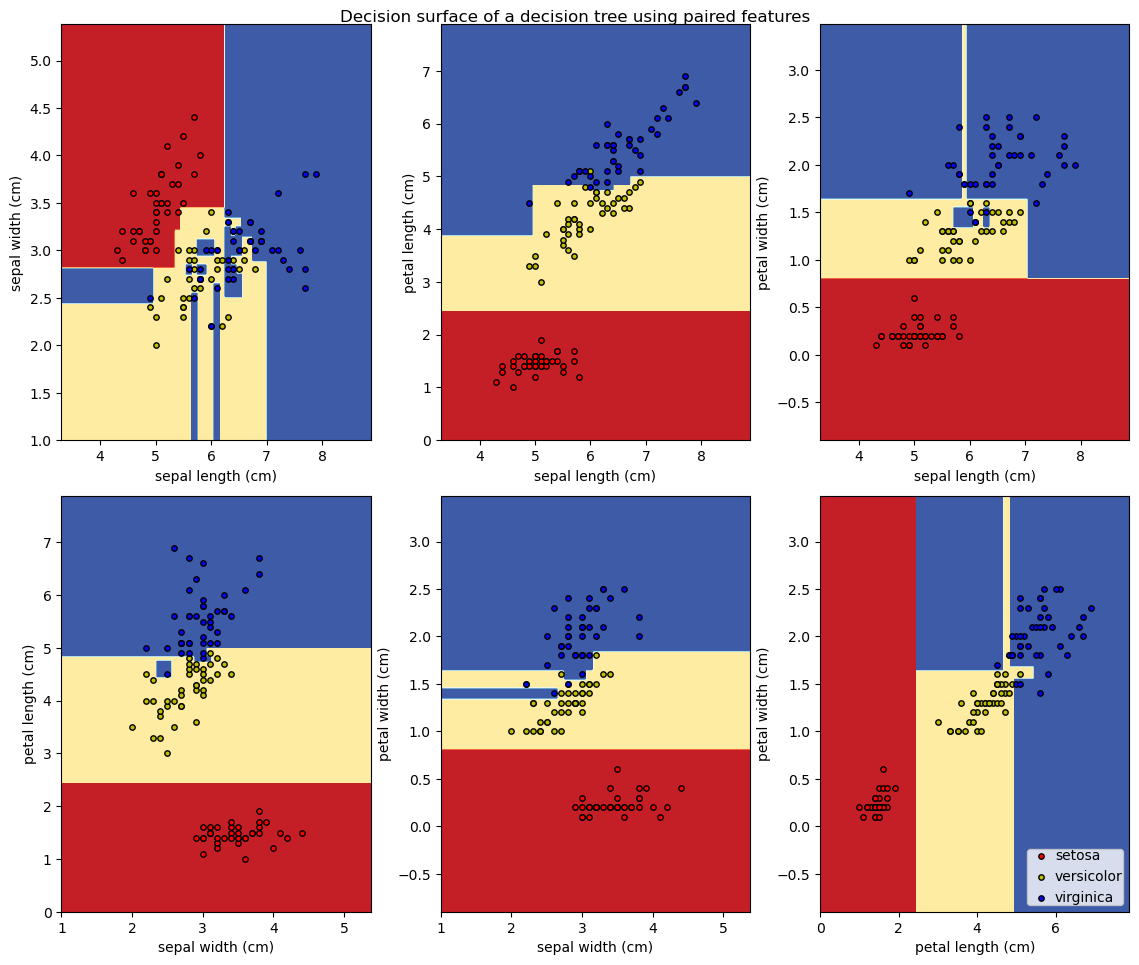

In [7]:
model = decision_boundary(train_x, train_y)

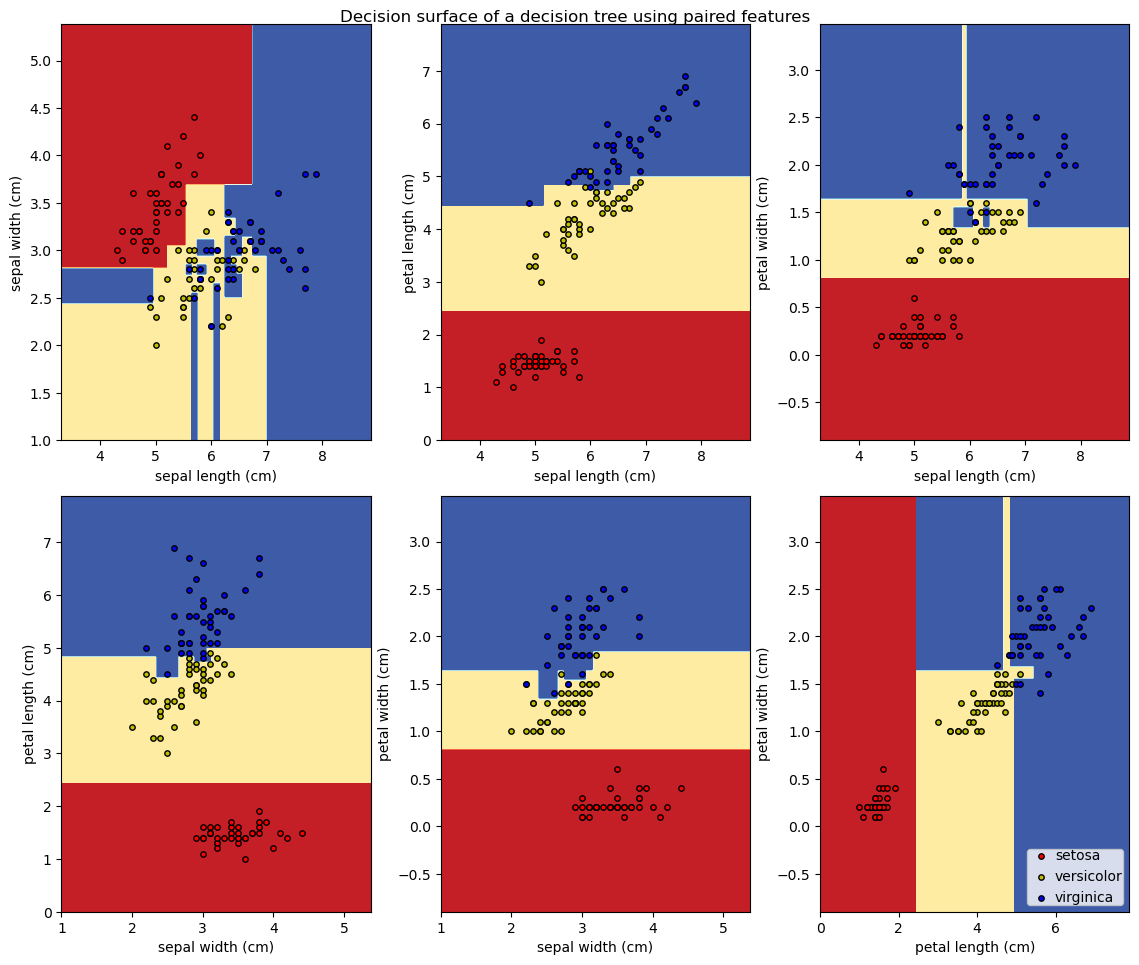

In [8]:
model = decision_boundary(train_x, train_y, method = 'entropy')

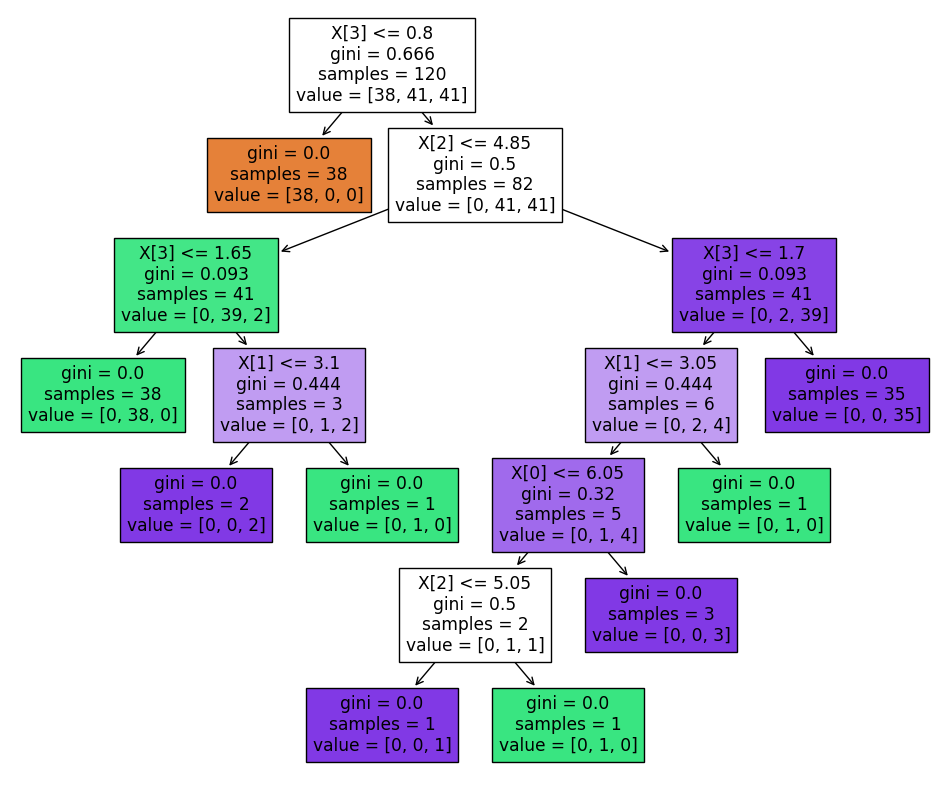

In [9]:
plt.figure(figsize = (12, 10))
clf = tree.DecisionTreeClassifier().fit(train_x, train_y)
tree.plot_tree(clf, filled=True)
plt.show()

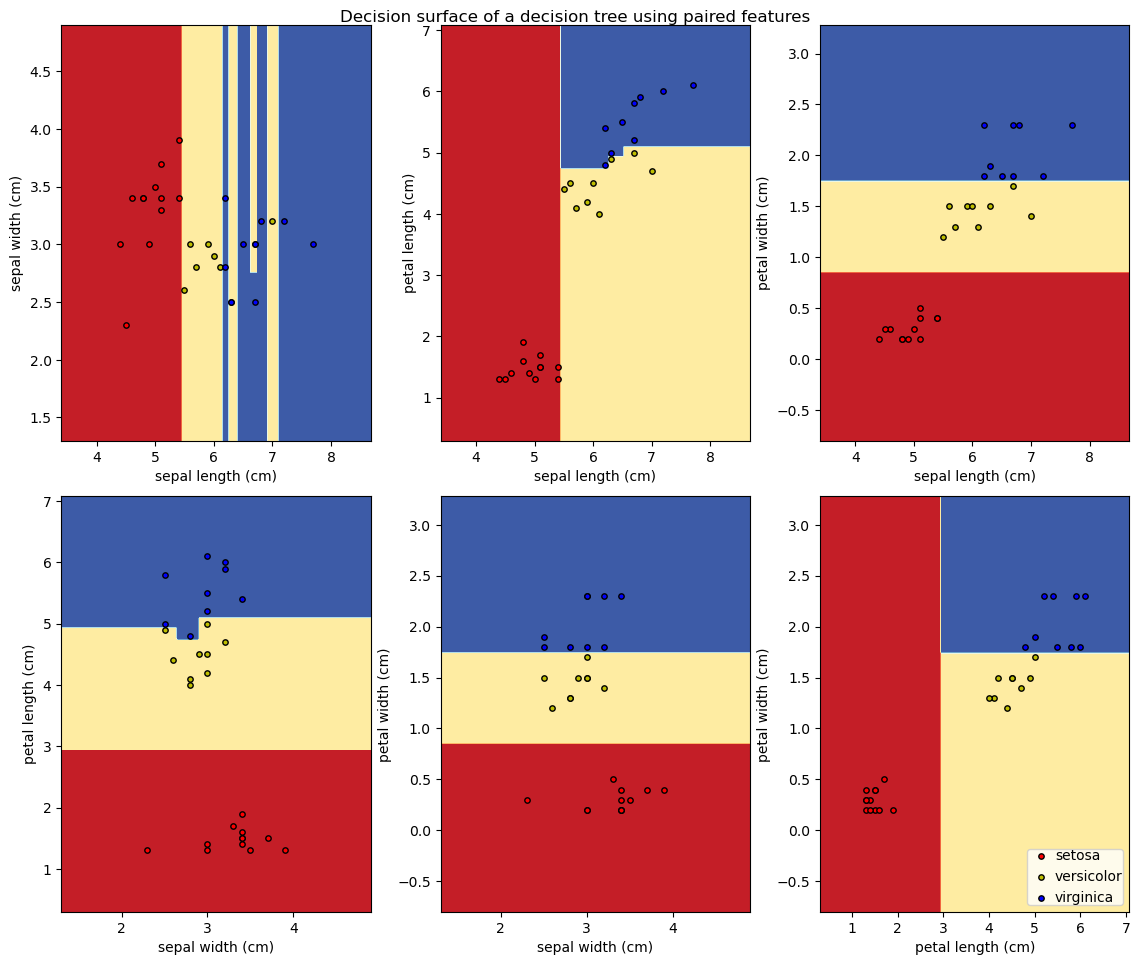

DecisionTreeClassifier()

In [10]:
decision_boundary(test_x, test_y)

In [11]:
tree_model = tree.DecisionTreeClassifier().fit(train_x, train_y) #Tree training
print('The proportion of the points that are correctly classified is %f'%metrics.accuracy_score(test_y, tree_model.predict(test_x)))

The proportion of the points that are correctly classified is 0.933333


In [12]:
print('The depth of the tree is %i'%tree_model.get_depth())#depth = 6

The depth of the tree is 6


In [13]:
correct_rate = dict()
for depth in range(1, 7):
    tree_model = tree.DecisionTreeClassifier(max_depth = depth).fit(train_x, train_y)
    print('The depth is %i'%depth)
    print('The correct rate is %f'%metrics.accuracy_score(test_y, tree_model.predict(test_x)))


The depth is 1
The correct rate is 0.700000
The depth is 2
The correct rate is 0.900000
The depth is 3
The correct rate is 0.933333
The depth is 4
The correct rate is 0.933333
The depth is 5
The correct rate is 0.966667
The depth is 6
The correct rate is 0.933333
